# Task 1 — Heatmap


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('netflix_catalogue.csv')

print(f"Loaded: {len(df)} titles")
print(df.head())

Loaded: 3000 titles
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


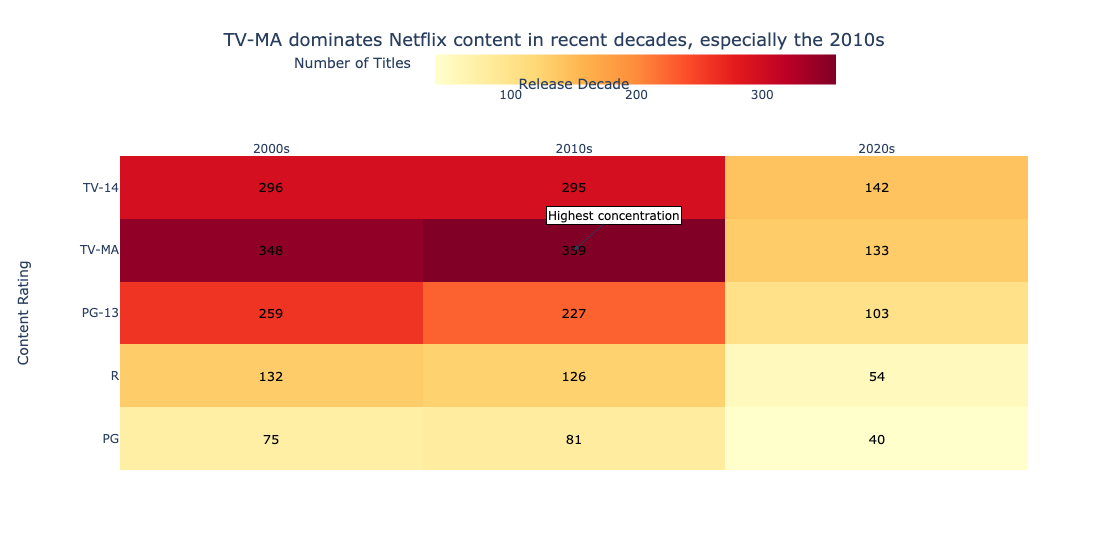

In [14]:
# Task 1 — Heatmap: content by rating and release decade

import pandas as pd
import plotly.graph_objects as go

# Eğer df tanımlı değilse veriyi tekrar yükle
df = pd.read_csv('netflix_catalogue.csv')

# 1. Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# 2. Filter required ratings
selected_ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
df_task1 = df[df['rating'].isin(selected_ratings)]

# 3. Create pivot table
heatmap_data = df_task1.pivot_table(
    index='rating',
    columns='decade',
    values='type',
    aggfunc='count',
    fill_value=0
)

# 4. Sort decades and rating order
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)
heatmap_data = heatmap_data.reindex(selected_ratings)

# 5. Create text values for cells
cell_text = heatmap_data.astype(str).values

# 6. Create heatmap similar to the example
fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns,
        y=heatmap_data.index,
        colorscale='YlOrRd',
        text=cell_text,
        texttemplate='%{text}',
        textfont=dict(size=13, color='black'),
        colorbar=dict(
            title='Number of Titles',
            orientation='h',
            x=0.5,
            y=1.15,
            xanchor='center',
            len=0.6
        )
    )
)

# 7. Annotation directly on one important cell
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Highest concentration',
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-35,
    font=dict(size=12, color='black'),
    bgcolor='white',
    bordercolor='black',
    borderwidth=1
)

# 8. Layout styling
fig.update_layout(
    title=dict(
        text='TV-MA dominates Netflix content in recent decades, especially the 2010s',
        x=0.5,
        font=dict(size=18)
    ),
    xaxis=dict(
        title='Release Decade',
        side='top'
    ),
    yaxis=dict(
        title='Content Rating',
        autorange='reversed'
    ),
    width=900,
    height=550,
    plot_bgcolor='white',
    margin=dict(l=120, r=80, t=130, b=80)
)

fig.show()

Index(['type', 'release_year', 'added_year', 'genre', 'country', 'rating',
       'duration'],
      dtype='object')
   added_year  count
0        2015     71
1        2016     93
2        2017     77
3        2018     79
4        2019     93
5        2020     81
6        2021     83
7        2022     82


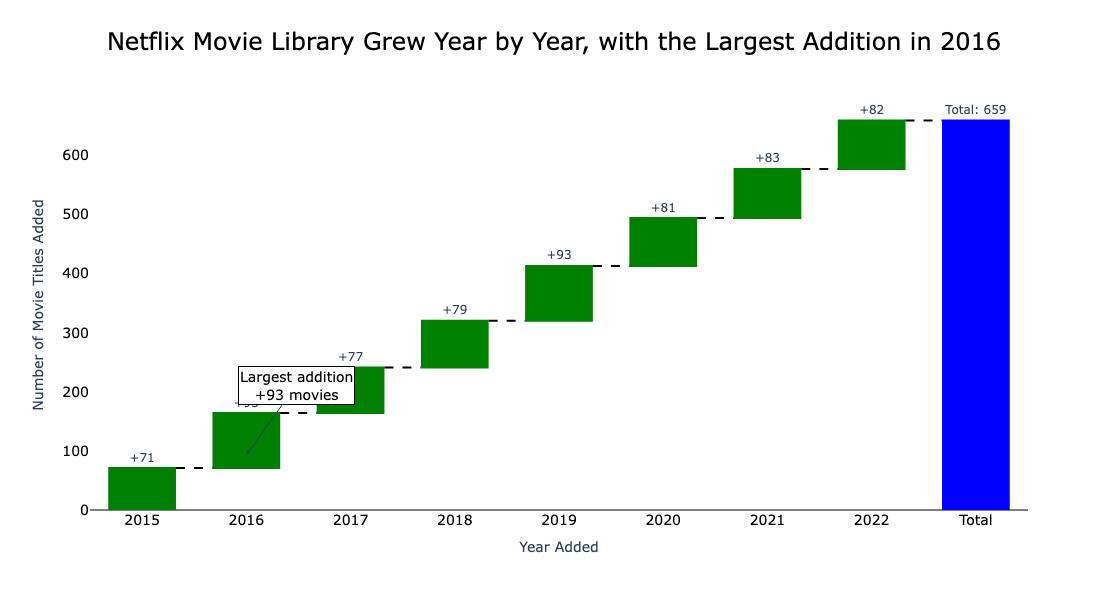

In [16]:
# Task 2 — Waterfall: Netflix Movie additions by year

import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("netflix_catalogue.csv")

# Check columns
print(df.columns)

# Filter only Movies
movies = df[df["type"] == "Movie"].copy()

# Keep 2015 to 2022
movies = movies[
    movies["added_year"].between(2015, 2022)
].copy()

# Count movies added per year
movie_additions = (
    movies
    .groupby("added_year")
    .size()
    .reindex(range(2015, 2023), fill_value=0)
    .reset_index(name="count")
)

# Clean data types
movie_additions["added_year"] = movie_additions["added_year"].astype(int)
movie_additions["count"] = movie_additions["count"].astype(int)

# Print table to verify
print(movie_additions)

# Find largest single addition
largest_row = movie_additions.loc[movie_additions["count"].idxmax()]
largest_year = int(largest_row["added_year"])
largest_count = int(largest_row["count"])

# Labels
labels = movie_additions["added_year"].astype(str).tolist() + ["Total"]

# Numeric x positions to prevent Plotly from squeezing everything
x_positions = list(range(len(labels)))

# Waterfall values
y_values = movie_additions["count"].tolist() + [0]

# Measures
measure_values = ["relative"] * len(movie_additions) + ["total"]

# Text labels
text_values = [f"+{value}" for value in movie_additions["count"]] + [
    f"Total: {movie_additions['count'].sum()}"
]

# Create waterfall chart
fig = go.Figure()

fig.add_trace(
    go.Waterfall(
        x=x_positions,
        y=y_values,
        measure=measure_values,
        text=text_values,
        textposition="outside",
        connector=dict(
            line=dict(
                color="black",
                width=2,
                dash="dash"
            )
        ),
        increasing=dict(
            marker=dict(color="green")
        ),
        decreasing=dict(
            marker=dict(color="red")
        ),
        totals=dict(
            marker=dict(color="blue")
        )
    )
)

# Find position of largest addition year
largest_index = labels.index(str(largest_year))

# Add annotation
fig.add_annotation(
    x=largest_index,
    y=largest_count,
    text=f"Largest addition<br>+{largest_count} movies",
    showarrow=True,
    arrowhead=2,
    ax=50,
    ay=-70,
    font=dict(size=14, color="black"),
    bgcolor="white",
    bordercolor="black",
    borderwidth=1
)

# Layout
fig.update_layout(
    title=dict(
        text=f"Netflix Movie Library Grew Year by Year, with the Largest Addition in {largest_year}",
        x=0.5,
        font=dict(size=24, color="black")
    ),
    xaxis=dict(
        title="Year Added",
        tickmode="array",
        tickvals=x_positions,
        ticktext=labels,
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=14, color="black")
    ),
    yaxis=dict(
        title="Number of Movie Titles Added",
        showgrid=False,
        zeroline=True,
        zerolinecolor="gray",
        zerolinewidth=2,
        tickfont=dict(size=14, color="black")
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1000,
    height=600,
    margin=dict(l=90, r=80, t=100, b=90),
    showlegend=False,
    waterfallgap=0.35
)

fig.show()